In [ ]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
from pyspark.sql import functions as F


ROOT = Path("/home/jovyan/work/")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.spark import get_spark
from src.io import read_parquet, write_parquet
import src.config as cfg
from src.utils import print_header, shape 

from src.ml_utils import (
    create_clustering_pipeline,
    find_optimal_k,
    profile_clusters
)

# ANALISIS CON FEATURE ENGINERING

In [2]:
spark = get_spark("ClusteringPipeline")

# 1. Leer Features Finales (Salida de metricas.ipynb)
# Contiene: KPIs Financieros + Engagement Score + CAQ
df_features_raw = read_parquet(spark, cfg.FINAL_FEATURES_PATH)

# 2. Leer Clientes (Para perfilado demográfico posterior)
df_clients = read_parquet(spark, cfg.CLIENTS_PATH_CLEAN)

print_header("Datos Cargados para ML")
print(f"Total Clientes Disponibles: {df_features_raw.count():,}")


Datos Cargados para ML
Total Clientes Disponibles: 1,688,934


In [4]:
print_header("1. Selección de Variables para el Modelo")

# Seleccionamos solo las métricas de alto valor que creamos en el paso anterior.
# Evitamos usar IDs, Fechas o columnas intermedias que metan ruido.
SELECTED_FEATURES = [
    # Métricas Financieras
    "TOTAL_INCOME",
    "CREDIT_CARD_LIMIT",
    "PAYMENT_RATIO",
    "CUR",              # Credit Utilization Ratio
    "DEBT_TO_INCOME",   # Endeudamiento
    
    # Scores de Negocio
    "RM_SCORE",                 # Riesgo Morosidad
    "ENGAGEMENT_SCORE_TOTAL",   # Tu score complejo de 3 dimensiones
    
    # Dimensiones del Engagement (Opcional: Si quieres que el cluster sepa por qué tienen ese engagement)
    "SCORE_VARIEDAD",
    "SCORE_INTENSIDAD",
    "SCORE_HABITOS_SALUDABLES"
]

# Filtramos el DF para quedarnos con CLIENT_ID + Features Seleccionados
# Rellenamos nulos con 0 para evitar errores en el VectorAssembler
df_ml_ready = df_features_raw.select("CLIENT_ID", *SELECTED_FEATURES).na.fill(0)

print(f"Variables seleccionadas para Clustering: {len(SELECTED_FEATURES)}")
print(SELECTED_FEATURES)
shape(df_ml_ready)


1. Selección de Variables para el Modelo
Variables seleccionadas para Clustering: 10
['TOTAL_INCOME', 'CREDIT_CARD_LIMIT', 'PAYMENT_RATIO', 'CUR', 'DEBT_TO_INCOME', 'RM_SCORE', 'ENGAGEMENT_SCORE_TOTAL', 'SCORE_VARIEDAD', 'SCORE_INTENSIDAD', 'SCORE_HABITOS_SALUDABLES']


(1688934, 11)


2. Hyperparameter Tuning (K Óptimo)

Resultados Silhouette Score:
  K=2: 0.4176
  K=3: 0.3142
  K=4: 0.3710
  K=5: 0.3926
  K=6: 0.3748
  K=7: 0.3503
  K=8: 0.3675

✅ K óptimo recomendado: 2


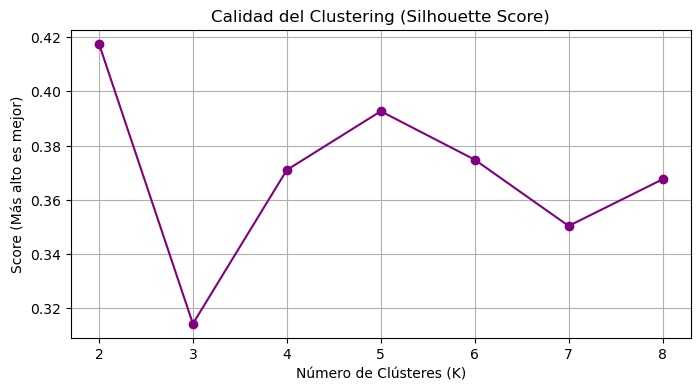

In [ ]:
print_header("2. Hyperparameter Tuning (K Óptimo)")

# Probamos de 2 a 8 clústeres
k_range = range(2, 9) 

# Encontrar el K óptimo usando Silhouette Score
scores = find_optimal_k(df_ml_ready, k_range)

print("\nResultados Silhouette Score:")
for k, score in scores.items():
    print(f"  K={k}: {score:.4f}")

# Selección automática del mejor K
k_optimo = max(scores, key=scores.get)
print(f"\n✅ K óptimo recomendado: {k_optimo}")

# Gráfico de Silhouette
plt.figure(figsize=(8, 4))
plt.plot(list(scores.keys()), list(scores.values()), marker='o', color='purple')
plt.title("Calidad del Clustering (Silhouette Score)")
plt.xlabel("Número de Clústeres (K)")
plt.ylabel("Score (Más alto es mejor)")
plt.grid(True)
plt.show()

In [6]:
print_header(f"3. Generando Embeddings y Clusters (K={k_optimo})")

# 1. Crear Pipeline (Scaler + KMeans)
# ml_utils se encarga de VectorAssembler y StandardScaler
pipeline = create_clustering_pipeline(df_ml_ready, k_clusters=k_optimo)

# 2. Entrenar Modelo
model = pipeline.fit(df_ml_ready)

# 3. Predecir (Asignar Cluster)
# 'prediction' es la columna con el número de cluster (0, 1, 2...)
df_segmented = model.transform(df_ml_ready).withColumnRenamed("prediction", "CLUSTER_ID")

# Mostrar distribución
count_df = df_segmented.groupBy("CLUSTER_ID").count().orderBy("CLUSTER_ID").toPandas()
print("\nDistribución de Clientes por Cluster:")
print(count_df)


3. Generando Embeddings y Clusters (K=2)

Distribución de Clientes por Cluster:
   CLUSTER_ID    count
0           0   657779
1           1  1031155


In [ ]:
print_header("4. Perfilado de los Segmentos")


# Perfilamos usando las variables que entraron al modelo
df_profile_num, _ = profile_clusters(df_segmented, "CLUSTER_ID")

print("Promedios por Cluster (Variables Normalizadas/Originales):")
df_profile_num.show(truncate=False)

# VISUALIZACIÓN RÁPIDA (PANDAS)
# Convertimos el perfil a Pandas para verlo mejor como mapa de calor
pdf_profile = df_profile_num.toPandas().set_index("CLUSTER_ID")
# Transponemos para facilitar lectura
print("\n--- Interpretación de Segmentos (Heatmap de Texto) ---")
print(pdf_profile.T)


4. Perfilado de los Segmentos
Promedios por Cluster (Variables Normalizadas/Originales):
+----------+------------------+----------------------+------------------+--------------------+-------------------+------------------+---------------------------+-------------------+---------------------+-----------------------------+
|CLUSTER_ID|MEAN_TOTAL_INCOME |MEAN_CREDIT_CARD_LIMIT|MEAN_PAYMENT_RATIO|MEAN_CUR            |MEAN_DEBT_TO_INCOME|MEAN_RM_SCORE     |MEAN_ENGAGEMENT_SCORE_TOTAL|MEAN_SCORE_VARIEDAD|MEAN_SCORE_INTENSIDAD|MEAN_SCORE_HABITOS_SALUDABLES|
+----------+------------------+----------------------+------------------+--------------------+-------------------+------------------+---------------------------+-------------------+---------------------+-----------------------------+
|0         |2243.2345739070415|2689.206551136476     |4.789694530957605 |0.7337982551768364  |0.12590023122342087|1.6441570801135337|77.62925997941558          |171.40517053093467 |46.29900772143836    |25.62

## Segmento 0: 
"El Cliente Heavy User / Comprometido"
Definición: Cliente altamente activo, con una fuerte dependencia de la línea de crédito y una interacción profunda con el banco. Es el cliente que "vive" a crédito.

### PERFILES: 
A pesar de tener ingresos similares al Segmento 1 (~2,243 vs ~2,110), este perfil tiene el doble de límite de crédito (~2,689) y hace un uso extensivo del mismo. Es un cliente que maximiza su capacidad financiera a través de la deuda.

### PATRONES DE COMPORTAMIENTO:

Alta Utilización (CUR): Su característica definitoria. Tienen un CUR del 73% (0.733), lo que indica que usan casi tres cuartas partes de su límite disponible constantemente.

Alto Engagement: Su Score de Variedad (171) y Score de Intensidad (46) son muy superiores. Utilizan la tarjeta para todo tipo de compras y en diversos canales.

Carga de Deuda: Tienen un ratio Deuda/Ingresos positivo (0.12), lo que indica que arrastran deuda mes a mes.

### RIESGO DE ABANDONO Y RIESGO CREDITICIO:

Riesgo de Fuga (Churn): Bajo. Su alto Engagement Score (77.6) sugiere que están "atados" al banco por sus productos y deudas. Es difícil que se vayan.

Riesgo Crediticio: Moderado-Alto. Su RM Score (Riesgo de Morosidad) es de 1.64, mucho más alto que el otro grupo. Al estar tan cerca de su límite (73%), cualquier shock financiero (desempleo) podría causar impagos.

### OPORTUNIDADES DE CRECIMIENTO:

Cross-selling de Pasivo: Dado que están endeudados, ofrecer consolidación de deuda o préstamos personales a menor tasa para liberar la tarjeta.

Aumento de Límites: Si su historial de pagos es bueno (Payment Ratio 4.7), aumentar el límite reduciría su CUR artificialmente, mejorando su perfil de riesgo.

### KPIS CLAVE:

Nivel de Morosidad (NPL): Vigilar estrictamente el RM Score.

Share of Wallet: Mantener su alta puntuación de variedad.

## Segmento 1: 
"El Cliente Transaccional / Conservador"
Definición: Cliente cauteloso, que usa la tarjeta raramente o solo como medio de pago (pagando el total a fin de mes), no como medio de financiación.

### PERFILES: 
Tienen ingresos estables (~2,110), pero límites de crédito bajos (~1,309), probablemente porque no los solicitan o el banco no se los ha subido por falta de uso. Financieramente parecen más saneados o "ahorradores".

### PATRONES DE COMPORTAMIENTO:

Nula Utilización (CUR): Su uso es apenas del 4% (0.04). La tarjeta está casi de adorno o para emergencias.

Saneamiento Financiero: Su ratio Deuda/Ingresos es negativo (-0.62), lo que sugiere que tienen más activos/ahorros que deudas visibles en este producto.

Baja Interacción: Su Score de Variedad es bajo (63). Usan la tarjeta para cosas muy puntuales.

### RIESGO DE ABANDONO Y RIESGO CREDITICIO:

Riesgo de Fuga (Churn): Alto. Su Engagement Score es bajo (40.5). Al no depender del crédito, pueden cambiar de banco fácilmente por una oferta mejor o dejar de usar la tarjeta (inactividad).

Riesgo Crediticio: Muy Bajo. Su RM Score es mínimo (0.23). Es muy improbable que este cliente deje de pagar los pocos gastos que realiza.

### OPORTUNIDADES DE CRECIMIENTO:

Activación: Necesitan campañas de usage. Ejemplo: "Gasta 100€ al mes y recibe cashback". El objetivo es moverlos del 4% de uso al 15-20%.

Venta Cruzada de Ahorro/Inversión: Al tener deuda negativa (excedente de liquidez), son candidatos ideales para fondos de inversión, depósitos o planes de pensiones, más que para productos de crédito.

### KPIS CLAVE:

Tasa de Activación: Lograr que realicen al menos 3 transacciones al mes.

Churn Rate: Monitorear su inactividad prolongada.

# ANALISIS BEHAVIOURAL

In [9]:
print_header("Cargando Datos Behavioural Clean")
df_beh = read_parquet(spark, cfg.BEHAVIOURAL_PATH_CLEAN)
shape(df_beh)


Cargando Datos Behavioural Clean


(1724854, 13)

In [ ]:
print_header("1. Generando Perfil de Comportamiento General (Promedios)")


# Lista de columnas numéricas comportamentales (del documento original)
cols_to_agg = [
    "CREDICT_CARD_BALANCE",
    "CREDIT_CARD_LIMIT",
    "CREDIT_CARD_DRAWINGS_ATM",
    "CREDIT_CARD_DRAWINGS_POS",
    "CREDIT_CARD_DRAWINGS_OTHER",
    "CREDIT_CARD_DRAWINGS",
    "CREDIT_CARD_PAYMENT",
    "NUMBER_DRAWINGS_ATM",
    "NUMBER_DRAWINGS",
    "NUMBER_INSTALMENTS"
]

# Expresiones de agregación (Media)
agg_exprs = [F.mean(col).alias(col) for col in cols_to_agg]

# Agrupamos por ID
df_beh_agg = df_beh.groupBy("CLIENT_ID").agg(*agg_exprs).na.fill(0)

print(f"Clientes únicos perfilados: {df_beh_agg.count():,}")
df_beh_agg.show(5)


1. Generando Perfil de Comportamiento General (Promedios)
Clientes únicos perfilados: 46,046
+------------+--------------------+------------------+------------------------+------------------------+--------------------------+--------------------+-------------------+-------------------+-------------------+------------------+
|   CLIENT_ID|CREDICT_CARD_BALANCE| CREDIT_CARD_LIMIT|CREDIT_CARD_DRAWINGS_ATM|CREDIT_CARD_DRAWINGS_POS|CREDIT_CARD_DRAWINGS_OTHER|CREDIT_CARD_DRAWINGS|CREDIT_CARD_PAYMENT|NUMBER_DRAWINGS_ATM|    NUMBER_DRAWINGS|NUMBER_INSTALMENTS|
+------------+--------------------+------------------+------------------------+------------------------+--------------------------+--------------------+-------------------+-------------------+-------------------+------------------+
|ES182405039N|   4739.241621621622|            5400.0|       279.4864864864865|      2.9675675675675675|                       0.0|   282.4540540540541|  304.3451351351352| 2.3513513513513513| 2.594594594594594

In [14]:
print_header("2. Preparando Datos para el Modelo")

# Seleccionamos ID + Las columnas promediadas
columnas_ml = ["CLIENT_ID"] + cols_to_agg
df_ml_beh = df_beh_agg.select(columnas_ml)

print(f"Variables utilizadas: {len(cols_to_agg)}")
print(cols_to_agg)


2. Preparando Datos para el Modelo
Variables utilizadas: 10
['CREDICT_CARD_BALANCE', 'CREDIT_CARD_LIMIT', 'CREDIT_CARD_DRAWINGS_ATM', 'CREDIT_CARD_DRAWINGS_POS', 'CREDIT_CARD_DRAWINGS_OTHER', 'CREDIT_CARD_DRAWINGS', 'CREDIT_CARD_PAYMENT', 'NUMBER_DRAWINGS_ATM', 'NUMBER_DRAWINGS', 'NUMBER_INSTALMENTS']



3. Hyperparameter Tuning (K Óptimo)

Resultados Silhouette Score (Behavioural Avg):
  K=2: 0.6901
  K=3: 0.3843
  K=4: 0.4009
  K=5: 0.4699
  K=6: 0.4759
  K=7: 0.4985
  K=8: 0.3865
  K=9: 0.4551

✅ K óptimo recomendado: 2


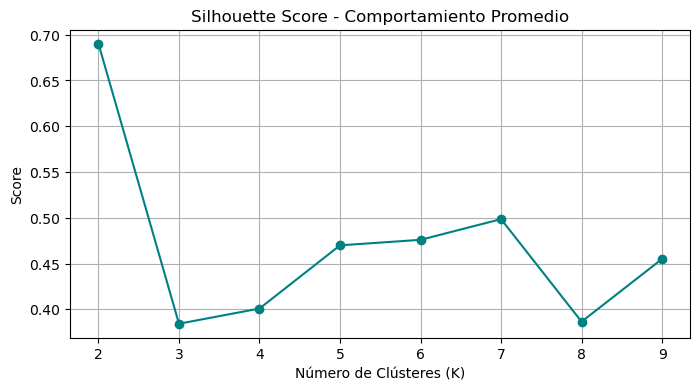

In [15]:
print_header("3. Hyperparameter Tuning (K Óptimo)")

# Probamos K de 2 a 9
k_range = range(2, 10) 
scores = find_optimal_k(df_ml_beh, k_range)

print("\nResultados Silhouette Score (Behavioural Avg):")
for k, score in scores.items():
    print(f"  K={k}: {score:.4f}")

# Selección automática
k_optimo = max(scores, key=scores.get)
print(f"\n✅ K óptimo recomendado: {k_optimo}")

# Gráfico
plt.figure(figsize=(8, 4))
plt.plot(list(scores.keys()), list(scores.values()), marker='o', color='teal')
plt.title("Silhouette Score - Comportamiento Promedio")
plt.xlabel("Número de Clústeres (K)")
plt.ylabel("Score")
plt.grid(True)
plt.show()

In [16]:
print_header(f"4. Generando Segmentos (K={k_optimo})")

# 1. Pipeline (Preprocesamiento + KMeans)
pipeline = create_clustering_pipeline(df_ml_beh, k_clusters=k_optimo)

# 2. Entrenar Modelo
model = pipeline.fit(df_ml_beh)

# 3. Predecir Segmentos
df_segmented_beh = model.transform(df_ml_beh).withColumnRenamed("prediction", "CLUSTER_BEH_GENERAL")

# Distribución
print("\nDistribución de Clientes por Cluster (General):")
df_segmented_beh.groupBy("CLUSTER_BEH_GENERAL").count().orderBy("CLUSTER_BEH_GENERAL").show()


4. Generando Segmentos (K=2)

Distribución de Clientes por Cluster (General):
+-------------------+-----+
|CLUSTER_BEH_GENERAL|count|
+-------------------+-----+
|                  0| 7490|
|                  1|38556|
+-------------------+-----+



In [ ]:
print_header("5. Perfilado de los Segmentos (Promedios Históricos)")


df_prof_num, _ = profile_clusters(df_segmented_beh, "CLUSTER_BEH_GENERAL")

print("Comportamiento Promedio por Cluster:")
df_prof_num.show(truncate=False)


5. Perfilado de los Segmentos (Promedios Históricos)
Comportamiento Promedio por Cluster:
+-------------------+-------------------------+----------------------+-----------------------------+-----------------------------+-------------------------------+-------------------------+------------------------+------------------------+--------------------+-----------------------+
|CLUSTER_BEH_GENERAL|MEAN_CREDICT_CARD_BALANCE|MEAN_CREDIT_CARD_LIMIT|MEAN_CREDIT_CARD_DRAWINGS_ATM|MEAN_CREDIT_CARD_DRAWINGS_POS|MEAN_CREDIT_CARD_DRAWINGS_OTHER|MEAN_CREDIT_CARD_DRAWINGS|MEAN_CREDIT_CARD_PAYMENT|MEAN_NUMBER_DRAWINGS_ATM|MEAN_NUMBER_DRAWINGS|MEAN_NUMBER_INSTALMENTS|
+-------------------+-------------------------+----------------------+-----------------------------+-----------------------------+-------------------------------+-------------------------+------------------------+------------------------+--------------------+-----------------------+
|0                  |2876.6158320001396       |5054.30222

## Segmento 0:	
Cliente Inactivo / "Dormido"	Tiene tarjeta, pero su uso es casi nulo. El límite y saldo son bajos. Podrían ser clientes de bajo riesgo, pero con bajo potencial de ingresos para el banco.

## Segmento 1:	
Cliente Activo / "Premium" / Alto Riesgo	Alta utilización de la tarjeta, alta deuda, altos límites y altos pagos. Es el principal motor de ingresos por intereses y comisiones, pero también podría ser el principal motor de riesgo de crédito.

### PERFILES:
Tenemos dos perfiles diferentes en cada segmento, el cliente que usa la tarjeta activamente (S1) y el cliente inactivo (S0). Ahora puedes añadir variables demográficas (edad, ingresos) a este perfil para decir: "El S1 es un cliente activo, joven y de altos ingresos".

### PATRONES DE COMPORTAMIENTO:
El patrón clave es el uso intensivo de crédito. El patrón de comportamiento en S1 es de alto consumo y alta deuda rotatoria, mientras que el patrón en S0 es de inactividad total.

### RIESGO DE ABANDONO Y RIESGO CREDITICIO:
Riesgo de Abandono (S0): El Segmento 0 es altamente vulnerable al churn. Si no usan el producto, es fácil que cambien de banco o cancelen. Oportunidad: Crear campañas de engagement.

Riesgo de Pérdida de Rentabilidad/Riesgo Crediticio (S1): El Segmento 1 es altamente rentable, pero su alta deuda ($2,753 de saldo promedio) y altos reintegros en cajeros (DRAWINGS_ATM) sugieren que están cerca de su límite. Riesgo: Si pierden ingresos, podrían entrar en impago.

### OPORTUNIDADES DE CRECIMIENTO:
Oportunidad (S0): Los clientes inactivos son un objetivo fácil para cross-selling de productos complementarios o para campañas de activación (ej. ofertas de cashback para la primera compra).

Oportunidad (S1): Dado su alto nivel de confianza en el banco (altos límites), pueden ser candidatos para préstamos personales de mayor valor o productos de inversión.

## KPIS:
KPI Primario para S0 (Inactivos): Tasa de Activación Mensual (porcentaje de S0 que realiza una compra o retiro).

KPI Primario para S1 (Activos): Tasa de Utilización del Límite (MEAN_CREDIT_CARD_BALANCE / MEAN_CREDIT_CARD_LIMIT). Si es muy alta (cerca del 80-90%), el cliente está cerca del sobreendeudamiento, lo que activa una señal de riesgo.